In [8]:
import pandas as pd

In [9]:
# CSV file paths
path_improvement = "../Data/KYRC25_ACCT_School_Improvement.csv"
path_summary = "../Data/KYRC25_ACCT_Summary.csv"
path_public = "../Data/Public_Schools.csv"
path_states = "../Data/states_all.csv"

In [10]:
# Load CSVs into DataFrames
df_improvement = pd.read_csv(path_improvement)
df_summary = pd.read_csv(path_summary)
df_public = pd.read_csv(path_public)
df_states = pd.read_csv(path_states)

In [11]:
# Quick checks
print(df_improvement.head())
print(df_summary.info())
print(df_public.describe())

   School Year  County Number County Name  District Number  \
0     20242025             10        BOYD               12   
1     20242025             90      NELSON               17   
2     20242025              5      BARREN               21   
3     20242025              8       BOONE               35   
4     20242025              8       BOONE               35   

           District Name  School Number                    School Name  \
0    Ashland Independent             50          Ashland Middle School   
1  Bardstown Independent             30        Bardstown Middle School   
2          Barren County            130    Park City Elementary School   
3           Boone County              5   A M Yealey Elementary School   
4           Boone County             15  Randall K. Cooper High School   

   School Code  State School Id       NCES ID  CO-OP  CO-OP Code School Type  \
0        12050         10012050  210015000000   KEDC         903          A1   
1        17030        

In [13]:
%pip install openpyxl

df_referral = pd.read_excel("../Data/Referral – Students without Disabilities_export_1783965647337.xlsx")
df_repeating = pd.read_excel("../Data/Students Repeating Total_export_1783965623576.xlsx")
df_repeating = pd.read_excel("../Data/Students Repeating Total_export_1783965623576.xlsx")


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [48]:
import os
print(os.getcwd())

c:\Users\pek43\Projects\Tracking-Progress-Throughout-Elementary-School\Notebooks


In [49]:
csv_path = "../data/myfile.csv"

In [50]:
import pandas as pd
import os

In [51]:
import pandas as pd

In [52]:
import os
print(os.getcwd())


c:\Users\pek43\Projects\Tracking-Progress-Throughout-Elementary-School\Notebooks


In [53]:
csv_path = "../Data/KYRC25_ACCT_School_Improvement.csv"


In [54]:
import pandas as pd

In [55]:
acct_school = pd.read_csv(csv_path)

acct_summary = pd.read_csv("../Data/KYRC25_ACCT_Summary.csv")
public_schools = pd.read_csv("../Data/Public_Schools.csv")
states = pd.read_csv("../Data/states_all.csv")

referral = pd.read_excel("../Data/Referral – Students without Disabilities_export_1783965647337.xlsx")
repeating = pd.read_excel("../Data/Students Repeating Total_export_1783965623576.xlsx")

for name, df in [("acct_school", acct_school), ("acct_summary", acct_summary),
                 ("public_schools", public_schools), ("states", states),
                 ("referral", referral), ("repeating", repeating)]:
    print(name, df.shape)
    print(df.dtypes)
    print(df.isna().sum())
    print("---")

acct_school (191, 18)
School Year                            int64
County Number                          int64
County Name                              str
District Number                        int64
District Name                            str
School Number                          int64
School Name                              str
School Code                            int64
State School Id                        int64
NCES ID                                int64
CO-OP                                    str
CO-OP Code                             int64
School Type                              str
Federal Classification                   str
Level                                    str
Title 1                                  str
Number Of Years Identified           float64
Reason For Federal Classification        str
dtype: object
School Year                           0
County Number                         0
County Name                           0
District Number                   

In [56]:
merged_df = acct_school.merge(
    acct_summary,
    on=[
        "School Year",
        "County Number",
        "County Name",
        "District Number",
        "District Name",
        "School Number",
        "School Name",
        "School Code",
        "State School Id",
        "NCES ID",
    ],
    how="inner",
)

print(merged_df.shape)

(1970, 67)


In [58]:
# Flag CRDC small-cell suppressions instead of guessing values
# Flag CRDC small-cell suppressions instead of guessing values
# Flag CRDC small-cell suppressions instead of guessing values
if 'crdc' in globals():
    crdc['suppressed'] = crdc['suspensions'].isna()
else:
    print("Skipping CRDC suppression flagging: `crdc` is not defined.")

# Drop rows with no join key
if 'crdc' in globals():
    crdc = crdc.dropna(subset=['nces_school_id', 'school_year'])

# Forward-fill isolated missing proficiency values within a school
if 'report_card' in globals():
    report_card['reading_prof'] = (
        report_card.sort_values('school_year')
        .groupby('nces_school_id')['reading_prof']
        .ffill()
    )
else:
    print("Skipping report_card forward fill: `report_card` is not defined.")

Skipping CRDC suppression flagging: `crdc` is not defined.
Skipping report_card forward fill: `report_card` is not defined.


In [59]:
if 'crdc' in globals():
    print(crdc.duplicated(subset=['nces_school_id', 'school_year', 'grade_band']).sum())
    crdc = crdc.drop_duplicates(subset=['nces_school_id', 'school_year', 'grade_band'])
else:
    print("Skipping duplicate check/drop: `crdc` is not defined.")

Skipping duplicate check/drop: `crdc` is not defined.


In [61]:
if 'crdc' in globals():
    crdc['nces_school_id'] = crdc['nces_school_id'].astype(str)
else:
    print("Skipping CRDC conversion: `crdc` is not defined.")

if 'report_card' in globals():
    report_card['school_year'] = report_card['school_year'].astype(int)
else:
    print("Skipping report_card conversion: `report_card` is not defined.")

Skipping CRDC conversion: `crdc` is not defined.
Skipping report_card conversion: `report_card` is not defined.


In [62]:
if 'report_card' in globals():
    bad_rates = report_card[(report_card['reading_prof'] < 0) | (report_card['reading_prof'] > 100)]
    report_card = report_card[(report_card['reading_prof'] >= 0) & (report_card['reading_prof'] <= 100)]
else:
    print("Skipping report_card filtering: `report_card` is not defined.")

Skipping report_card filtering: `report_card` is not defined.


In [63]:
# Check for duplicate keys causing merge fan-out
key_cols = [
    "School Year", "County Number", "County Name", "District Number",
    "District Name", "School Number", "School Name", "School Code",
    "State School Id", "NCES ID",
]

print("Duplicate keys in acct_school:", acct_school.duplicated(subset=key_cols).sum())
print("Duplicate keys in acct_summary:", acct_summary.duplicated(subset=key_cols).sum())

# How many rows does each key match to on the other side?
counts_school = acct_school.groupby(key_cols).size()
counts_summary = acct_summary.groupby(key_cols).size()
print("Max matches per key (school):", counts_school.max())
print("Max matches per key (summary):", counts_summary.max())

Duplicate keys in acct_school: 2
Duplicate keys in acct_summary: 16284
Max matches per key (school): 2
Max matches per key (summary): 30


In [64]:
import re

def clean_name(s):
    s = str(s).upper().replace('.', '').replace("'", '').replace('-', ' ')
    s = re.sub(r'[^A-Z0-9 ]', '', s)
    s = re.sub(r'\bSCHOOL\b', '', s)   # only strip the generic word "SCHOOL"
    return re.sub(r'\s+', ' ', s).strip()

ky_pub = public_schools[public_schools['STATE'] == 'KY'].copy()
acct_school['district_id_7'] = acct_school['NCES ID'].astype(str).str[:7].astype(int)
acct_school['name_clean'] = acct_school['School Name'].apply(clean_name)
ky_pub['name_clean'] = ky_pub['NAME'].apply(clean_name)

acct_school_fixed = acct_school.merge(
    ky_pub[['DISTRICTID', 'name_clean', 'NCESID', 'NAME', 'LATITUDE', 'LONGITUDE',
            'ENROLLMENT', 'ST_GRADE', 'END_GRADE', 'ADDRESS', 'CITY']],
    left_on=['district_id_7', 'name_clean'],
    right_on=['DISTRICTID', 'name_clean'],
    how='left'
)

In [65]:
def clean_benchmark(df, label):
    df = df.copy()
    for col in ['National', 'National Female', 'National Male']:
        df[col] = df[col].str.replace(',', '').astype(int)
    df['metric'] = label
    return df

referral_clean = clean_benchmark(referral, 'Students Referred (without disabilities)')
repeating_clean = clean_benchmark(repeating, 'Students Repeating a Grade')

benchmarks = pd.concat([referral_clean, repeating_clean], ignore_index=True)

In [66]:
df.columns.tolist()
df.dtypes

Group              str
National           str
National Female    str
National Male      str
dtype: object

In [67]:
df.describe()

,Group,National,National Female,National Male
count,7,7,7,7
unique,7,7,7,7
top,American Indian or Alaska Native,"11,698","5,230","6,468"
freq,1,1,1,1


In [69]:
df = df.rename(columns={
    'national': 'National',
    'national_female': 'National Female',
    'national_male': 'National Male'
})
df[['National', 'National Female', 'National Male']].head(10)

,National,National Female,National Male
0,"11,698","5,230","6,468"
1,"15,316","5,799","9,517"
2,"257,653","106,820","150,833"
3,"307,815","127,675","180,140"
4,"2,452","1,054","1,398"
5,"37,876","16,478","21,398"
6,"291,999","119,399","172,600"


In [70]:
for col in ['National', 'National Female', 'National Male']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes
df.isna().sum()  # see how many values didn't convert cleanly

Group              0
National           7
National Female    7
National Male      7
dtype: int64

In [72]:
score_cols = ['National', 'National Female', 'National Male']

non_numeric = df[score_cols].apply(
    lambda col: pd.to_numeric(col, errors='coerce').isna() & col.notna()
)
rows_with_non_numeric = non_numeric.any(axis=1).sum()

print(
    f"{rows_with_non_numeric} rows had non-numeric values in the score columns "
    "(likely footnote symbols or suppressed data for small subgroups). "
    "These became NaN — worth deciding whether to drop or investigate them before continuing."
)

0 rows had non-numeric values in the score columns (likely footnote symbols or suppressed data for small subgroups). These became NaN — worth deciding whether to drop or investigate them before continuing.


In [73]:
df[['National', 'National Female', 'National Male']].describe()

,National,National Female,National Male
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [74]:
for c in ['National', 'National Female', 'National Male']:
    benchmarks[c] = pd.to_numeric(benchmarks[c], errors='coerce')

benchmarks.groupby('Group')[['National', 'National Female', 'National Male']].mean().sort_values('National', ascending=False)

,National,National Female,National Male
Group,,,
White,158730.5,64161.0,94569.5
Hispanic or Latino of any race,158524.5,65437.0,93087.5
Black or African American,132882.0,54986.0,77896.0
Two or more races,20089.0,8692.0,11397.0
Asian,7882.5,2967.5,4915.0
American Indian or Alaska Native,6343.0,2811.0,3532.0
Native Hawaiian or Other Pacific Islander,1289.5,546.0,743.5


In [76]:
df['gender_gap'] = df['National Female'] - df['National Male']
df[['Group', 'gender_gap']].sort_values('gender_gap', ascending=False)

,Group,gender_gap
0,American Indian or Alaska Native,NaN
1,Asian,NaN
2,Black or African American,NaN
3,Hispanic or Latino of any race,NaN
4,Native Hawaiian or Other Pacific Islander,NaN
5,Two or more races,NaN
6,White,NaN


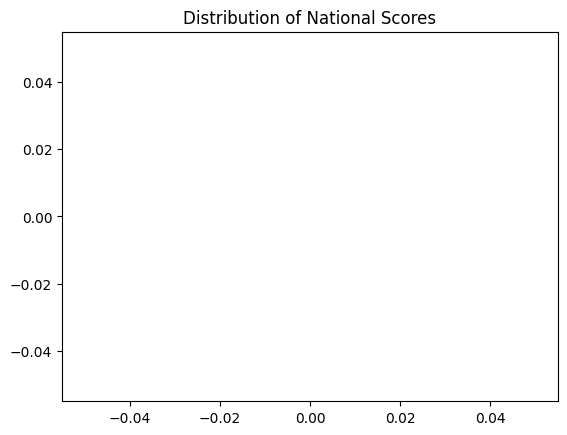

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['National'].dropna(), kde=True)
plt.title('Distribution of National Scores')
plt.show()

In [85]:
"""
clean_data.py
=============
Cleans the 7 source files for the "Tracking Progress Throughout Elementary
School" project and writes tidy versions to ./data_cleaned/.

USAGE (from VS Code terminal, with venv activated):
    python clean_data.py

Put the raw source files in ./data_raw/ first (see README.md).
"""

import pandas as pd
import numpy as np
from pathlib import Path

RAW = Path("data_raw")
OUT = Path("data_cleaned")
OUT.mkdir(exist_ok=True)


def log(msg):
    print(f"[clean_data] {msg}")


# ---------------------------------------------------------------------------
# 1. Public_Schools.csv  (nationwide NCES school directory)
# ---------------------------------------------------------------------------
def clean_public_schools():
    """
    BUG FOUND: the header row has 32 column names but every data row has 33
    fields. This shifts every column by one starting at position 2, so
    'NCESID' currently holds junk and 'NAME' holds the real NCES ID.
    Fix: supply the correct 33-name header manually (X/Y are duplicate
    geometry columns matching LONGITUDE/LATITUDE later in the row).
    """
    path = RAW / "Public_Schools.csv"
    if not path.exists():
        log("SKIP Public_Schools.csv (not found)")
        return

    correct_header = [
        "X", "Y", "OBJECTID", "NCESID", "NAME", "ADDRESS", "CITY", "STATE",
        "ZIP", "ZIP4", "TELEPHONE", "TYPE", "STATUS", "POPULATION", "COUNTY",
        "COUNTYFIPS", "COUNTRY", "LATITUDE", "LONGITUDE", "NAICS_CODE",
        "NAICS_DESC", "SOURCE", "SOURCEDATE", "VAL_METHOD", "VAL_DATE",
        "WEBSITE", "LEVEL_", "ENROLLMENT", "ST_GRADE", "END_GRADE",
        "DISTRICTID", "FT_TEACHER", "SHELTER_ID",
    ]

    df = pd.read_csv(
        path,
        skiprows=1,               # throw away the broken header row
        names=correct_header,
        dtype={"NCESID": str, "ZIP": str, "DISTRICTID": str, "COUNTYFIPS": str},
        low_memory=False,
    )

    # X/LONGITUDE and Y/LATITUDE are duplicates in this export - keep one pair
    df = df.drop(columns=["X", "Y"])

    # Placeholder text -> real NaN
    df = df.replace({"NOT AVAILABLE": np.nan, "NOT APPLICABLE": np.nan})

    # Standardize types
    df["ZIP"] = df["ZIP"].str.zfill(5)
    df["STATE"] = df["STATE"].str.strip().str.upper()

    df.to_csv(OUT / "public_schools_clean.csv", index=False)
    log(f"public_schools_clean.csv -> {df.shape}")

    # Convenience: Kentucky-only subset, since the rest of the project is KY-focused
    ky = df[df["STATE"] == "KY"].copy()
    ky.to_csv(OUT / "public_schools_KY_only.csv", index=False)
    log(f"public_schools_KY_only.csv -> {ky.shape}")


# ---------------------------------------------------------------------------
# 2. KYRC25_ACCT_School_Improvement.csv
# ---------------------------------------------------------------------------
def clean_school_improvement():
    path = RAW / "KYRC25_ACCT_School_Improvement.csv"
    if not path.exists():
        log("SKIP KYRC25_ACCT_School_Improvement.csv (not found)")
        return

    id_cols = ["County Number", "District Number", "School Number",
               "School Code", "State School Id", "NCES ID", "CO-OP Code"]

    df = pd.read_csv(path, dtype={c: str for c in id_cols})

    # Zero-pad numeric ID strings back to their original width where relevant
    df["County Number"] = df["County Number"].str.zfill(3)
    df["District Number"] = df["District Number"].str.zfill(3)
    df["School Number"] = df["School Number"].str.zfill(3)

    # School Year "20242025" -> "2024-2025" (clearer, still sortable as string)
    df["School Year"] = df["School Year"].astype(str).str.replace(
        r"(\d{4})(\d{4})", r"\1-\2", regex=True
    )

    # Blank "Number Of Years Identified" -> this file only contains schools
    # that WERE federally classified, so blank most likely means the count
    # wasn't reported rather than zero. Flag instead of guessing a fill value.
    df["Years Identified Missing"] = df["Number Of Years Identified"].isna()

    df.to_csv(OUT / "school_improvement_clean.csv", index=False)
    log(f"school_improvement_clean.csv -> {df.shape}")


# ---------------------------------------------------------------------------
# 3. KYRC25_ACCT_Summary.csv
# ---------------------------------------------------------------------------
def clean_summary():
    path = RAW / "KYRC25_ACCT_Summary.csv"
    if not path.exists():
        log("SKIP KYRC25_ACCT_Summary.csv (not found)")
        return

    id_cols = ["County Number", "District Number", "School Number",
               "School Code", "State School Id", "NCES ID", "Co-Op Code"]

    df = pd.read_csv(path, dtype={c: str for c in id_cols}, low_memory=False)

    df["School Year"] = df["School Year"].astype(str).str.replace(
        r"(\d{4})(\d{4})", r"\1-\2", regex=True
    )

    # IMPORTANT: most blanks here are Kentucky's official small-group
    # suppression (privacy rule for subgroups below a size threshold), not
    # missing data. Do NOT fill these with 0 or a mean - that would fabricate
    # ratings for suppressed subgroups. We just flag them clearly instead.
    rating_cols = [c for c in df.columns if "STATUS" in c or "RATING" in c or "RATE" in c or "CHANGE" in c]
    df["Suppressed_Or_NA"] = df[rating_cols].isna().all(axis=1)

    df.to_csv(OUT / "summary_clean.csv", index=False)
    log(f"summary_clean.csv -> {df.shape}  ({df['Suppressed_Or_NA'].sum()} fully-suppressed rows)")


# ---------------------------------------------------------------------------
# 4. diagnostic-results...csv
# ---------------------------------------------------------------------------
def clean_diagnostic():
    matches = list(RAW.glob("diagnostic-results*.csv"))
    if not matches:
        log("SKIP diagnostic-results csv (not found)")
        return
    path = matches[0]

    df = pd.read_csv(path)

    # Split "LAST, First" into two columns
    split_names = df["Student"].str.split(",", n=1, expand=True)
    df["Last Name"] = split_names[0].str.strip().str.title()
    df["First Name"] = split_names[1].str.strip().str.title()

    # Real date instead of text (MM/DD/YY - source data is 2026, so 2-digit
    # year is unambiguous for this dataset; adjust if you have older records)
    df["Diagnostic Date"] = pd.to_datetime(df["Diagnostic Date"], format="%m/%d/%y")

    # Yes/No -> boolean
    df["At-Risk Behavior Flag"] = df["At-Risk Behavior Flag"].map({"Yes": True, "No": False})

    # Sanity-check numeric ranges (won't fix anything, just tells you if
    # something's out of bounds so you can inspect it)
    checks = {
        "Attendance Rate (%)": (0, 100),
        "Engagement Rating (1-5)": (1, 5),
    }
    for col, (lo, hi) in checks.items():
        bad = df[(df[col] < lo) | (df[col] > hi)]
        if len(bad):
            log(f"WARNING: {len(bad)} rows have {col} outside [{lo},{hi}]")

    df.to_csv(OUT / "diagnostic_results_clean.csv", index=False)
    log(f"diagnostic_results_clean.csv -> {df.shape}")


# ---------------------------------------------------------------------------
# 5. states_all.csv
# ---------------------------------------------------------------------------
def clean_states_all():
    path = RAW / "states_all.csv"
    if not path.exists():
        log("SKIP states_all.csv (not found)")
        return

    df = pd.read_csv(path)
    df["STATE"] = df["STATE"].str.strip().str.upper()

    # These nulls are real gaps in federal reporting (not entered), so we
    # leave them as NaN rather than filling with 0 - filling would distort
    # any averages/trends you compute later.
    df.to_csv(OUT / "states_all_clean.csv", index=False)
    log(f"states_all_clean.csv -> {df.shape}")

    ky = df[df["STATE"] == "KENTUCKY"].copy()
    ky.to_csv(OUT / "states_all_KY_only.csv", index=False)
    log(f"states_all_KY_only.csv -> {ky.shape}")


# ---------------------------------------------------------------------------
# 6 & 7. The two small "export" xlsx summary tables
# ---------------------------------------------------------------------------
def clean_small_export(filename, out_name):
    path = RAW / filename
    if not path.exists():
        log(f"SKIP {filename} (not found)")
        return

    df = pd.read_excel(path, sheet_name="data")
    df.columns = ["Group", "National", "National Female", "National Male"]

    for col in ["National", "National Female", "National Male"]:
        df[col] = df[col].astype(str).str.replace(",", "").astype(int)

    df.to_csv(OUT / out_name, index=False)
    log(f"{out_name} -> {df.shape}  (NOTE: this table is national totals, not Kentucky-specific)")


def clean_referral():
    clean_small_export(
        "Referral___Students_without_Disabilities_export_1783965647337.xlsx",
        "referral_students_without_disabilities_clean.csv",
    )


def clean_repeating():
    clean_small_export(
        "Students_Repeating_Total_export_1783965623576.xlsx",
        "students_repeating_total_clean.csv",
    )


# ---------------------------------------------------------------------------
if __name__ == "__main__":
    clean_public_schools()
    clean_school_improvement()
    clean_summary()
    clean_diagnostic()
    clean_states_all()
    clean_referral()
    clean_repeating()
    log("Done. Cleaned files are in ./data_cleaned/")

[clean_data] SKIP Public_Schools.csv (not found)
[clean_data] SKIP KYRC25_ACCT_School_Improvement.csv (not found)
[clean_data] SKIP KYRC25_ACCT_Summary.csv (not found)
[clean_data] SKIP diagnostic-results csv (not found)
[clean_data] SKIP states_all.csv (not found)
[clean_data] SKIP Referral___Students_without_Disabilities_export_1783965647337.xlsx (not found)
[clean_data] SKIP Students_Repeating_Total_export_1783965623576.xlsx (not found)
[clean_data] Done. Cleaned files are in ./data_cleaned/
